# 09_2 — Execution timing: our bot vs the harness

Why the SAME edge looks great in the bot but negative in the harness — it's a
1-minute difference in WHEN the short is filled.

- **Our bot:** the minute-34 candle closes at 14:35:00 -> we send a market order
  the same second -> fill ≈ `close[34]` ≈ `open[35]` (the trigger price).
- **Harness:** at 1-minute decision frequency it can only act on the next bar and
  fills at its CLOSE = `close[35]` — a full minute later, after the fade already
  started. Not 'cheating' — it's *too pessimistic* for a sub-minute entry.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

PRE, EXIT, STOP = 60, 240, 0.03
paths = np.load('_out/pump_paths_2025.npy')
rel = 1.0 + paths          # price relative to trigger; column PRE = trigger bar
print('2025 pump events:', rel.shape[0])

2025 pump events: 2178


## Schematic: where each entry lands on the average pump path

[saved] notebooks\pump\_out\09_2_timeline.png
our entry (t=0): +0.00%   harness entry (t=+1): -0.76%   gap 0.76%


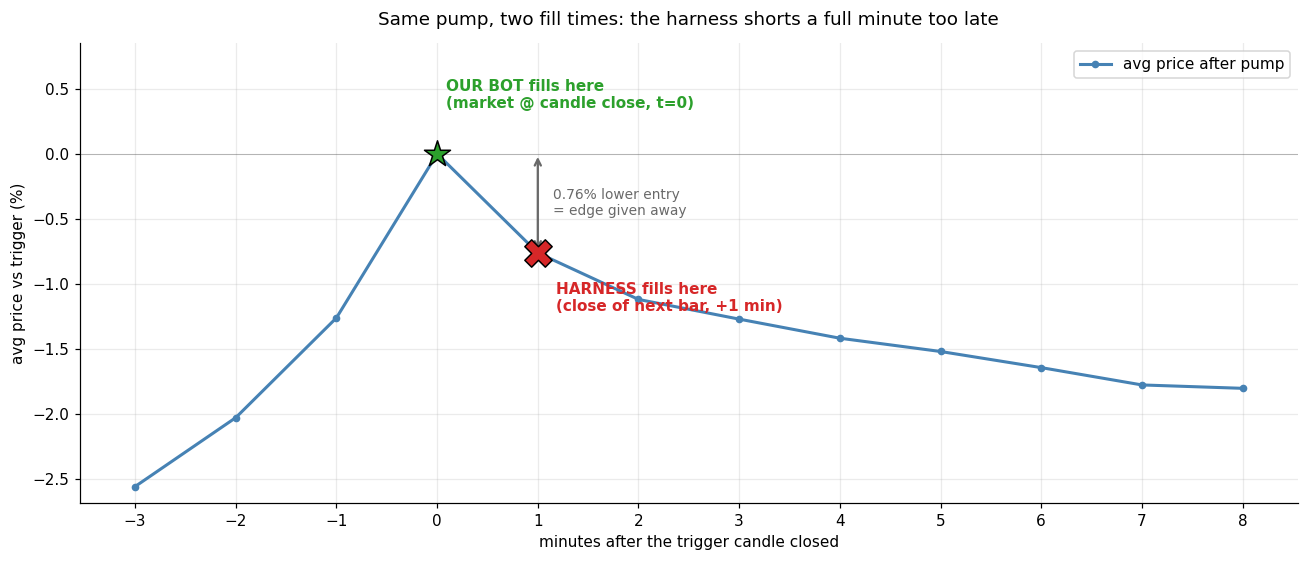

In [2]:
# average normalized path around the trigger, first minutes
lo, hi = -3, 8
off = np.arange(lo, hi + 1)
avg = (rel[:, PRE + lo:PRE + hi + 1].mean(axis=0) / rel[:, PRE].mean() - 1.0) * 100
# (normalize vs mean trigger level; tiny approximation, fine for a schematic)
avg = (np.array([ (rel[:, PRE + k] / rel[:, PRE]).mean() for k in off ]) - 1.0) * 100

p_our = avg[list(off).index(0)]     # our fill: trigger close (= open of next bar)
p_harn = avg[list(off).index(1)]    # harness fill: close of next bar

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.plot(off, avg, '-o', color='steelblue', lw=2, ms=4, label='avg price after pump')
ax.axhline(0, color='k', lw=0.5, alpha=0.3)

# our entry
ax.scatter([0], [p_our], s=320, marker='*', color='tab:green', zorder=6, edgecolor='k')
ax.annotate('OUR BOT fills here\n(market @ candle close, t=0)',
            (0, p_our), textcoords='offset points', xytext=(6, 30),
            color='tab:green', fontsize=10, fontweight='bold')
# harness entry
ax.scatter([1], [p_harn], s=320, marker='X', color='tab:red', zorder=6, edgecolor='k')
ax.annotate('HARNESS fills here\n(close of next bar, +1 min)',
            (1, p_harn), textcoords='offset points', xytext=(12, -38),
            color='tab:red', fontsize=10, fontweight='bold')
# the gap = lost short entry
ax.annotate('', xy=(1, p_harn), xytext=(1, p_our),
            arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.5))
ax.text(1.15, (p_our + p_harn) / 2, f'{p_our - p_harn:.2f}% lower entry\n= edge given away',
        fontsize=9, color='dimgray', va='center')

ax.set_xlabel('minutes after the trigger candle closed')
ax.set_ylabel('avg price vs trigger (%)')
ax.set_ylim(top=0.85)
ax.set_title('Same pump, two fill times: the harness shorts a full minute too late', pad=12)
ax.set_xticks(off)
ax.legend(loc='upper right')
show('09_2_timeline')
print(f'our entry (t=0): {p_our:+.2f}%   harness entry (t=+1): {p_harn:+.2f}%   gap {p_our-p_harn:.2f}%')

## Resulting per-trade edge by fill time (3% stop, 4h exit)

[saved] notebooks\pump\_out\09_2_edge_by_entry.png
our bot: +1.67%   harness: +0.72%   (gross, before the ~0.15% cost)


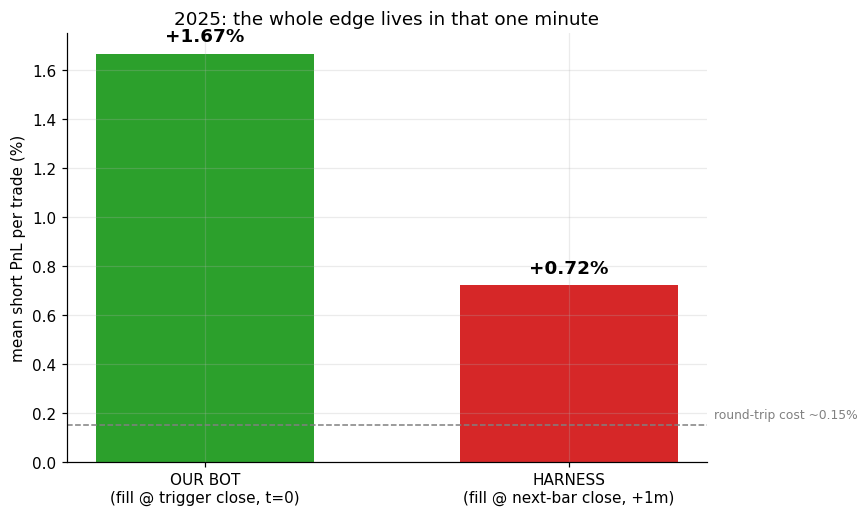

In [3]:
def edge_at(rel, entry_off):
    """mean short PnL % entering at offset `entry_off`, 3% stop, 4h exit."""
    base = PRE + entry_off
    p0 = rel[:, base]; thr = p0 * (1 + STOP)
    ex = rel[:, base + EXIT].copy()
    seg = rel[:, base + 1:base + EXIT + 1]
    for i in range(rel.shape[0]):
        h = np.where(seg[i] >= thr[i])[0]
        if len(h):
            ex[i] = rel[i, base + 1 + h[0]]
    pnl = 1.0 - ex / p0
    return pnl.mean() * 100

labels = ['OUR BOT\n(fill @ trigger close, t=0)', 'HARNESS\n(fill @ next-bar close, +1m)']
vals = [edge_at(rel, 0), edge_at(rel, 1)]
colors = ['tab:green', 'tab:red']

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(labels, vals, color=colors, width=0.6)
ax.axhline(0, color='k', lw=0.6)
ax.axhline(0.15, color='gray', ls='--', lw=1)
ax.text(1.4, 0.18, 'round-trip cost ~0.15%', color='gray', fontsize=8)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05, f'{v:+.2f}%', ha='center',
            fontsize=12, fontweight='bold')
ax.set_ylabel('mean short PnL per trade (%)')
ax.set_title('2025: the whole edge lives in that one minute')
show('09_2_edge_by_entry')
print(f'our bot: {vals[0]:+.2f}%   harness: {vals[1]:+.2f}%   (gross, before the ~0.15% cost)')